In [1]:
import pandas as pd
import anthropic
import json
import time
import re


df = pd.read_csv('yelp_restaurant_reviews.csv')

with open('../../Loan_Data_Analysis/api_key.txt', 'r') as file:
    my_api_key = file.read()

In [2]:
def rate_yelp_reviews(df: pd.DataFrame, text_column: str = "yelp_review", n_rows: int = 1000) -> pd.DataFrame:
    """
    Given dataframe with yelp_review column, sends each review to Claude API
    and obtains decimal ratings between 0 and 1 for food_quality, customer_service,
    atmosphere, and value. Returns a copy of the dataframe with scores added in.
    Uses Haiku for cost efficiency and the Batch API for a 50% discount.
    """
    client = anthropic.Anthropic(api_key=my_api_key)

    SYSTEM_PROMPT = """You are a restaurant review analyst. You will be given a Yelp review 
and must rate the following categories based solely on what the review mentions:

- food_quality: Quality, taste, freshness, and presentation of food
- customer_service: Friendliness, attentiveness, and professionalism of staff
- atmosphere: Ambiance, decor, cleanliness, noise level, and overall environment
- value: Price relative to quality, portion sizes, and overall worth

Rate each category on a decimal scale from 0.0 (worst) to 1.0 (best).
If a category is not mentioned in the review, return 0.5 for the score.

Respond with ONLY a JSON object in exactly this format, no explanation:
{"food_quality": 0.5, "customer_service": 0.7, "atmosphere": 0.3, "value": 0.8}"""

    subset = df.head(n_rows).copy()

    # Build batch requests
    requests = []
    for i, row in subset.iterrows():
        requests.append({
            "custom_id": str(i),
            "params": {
                "model": "claude-haiku-4-5-20251001",
                "max_tokens": 60,
                "system": SYSTEM_PROMPT,
                "messages": [
                    {"role": "user", "content": row[text_column]}
                ]
            }
        })

    # Submit batch 
    print(f"Submitting batch of {len(requests)} requests...")
    batch = client.messages.batches.create(requests=requests)
    batch_id = batch.id
    print(f"Batch submitted. ID: {batch_id}")

    # Poll until complete 
    while True:
        batch_status = client.messages.batches.retrieve(batch_id)
        status = batch_status.processing_status
        counts = batch_status.request_counts
        print(f"Status: {status} | "
              f"processing={counts.processing}, "
              f"succeeded={counts.succeeded}, "
              f"errored={counts.errored}")

        if status == "ended":
            break
        time.sleep(60)

    # Collect results
    CATEGORIES = ["food_quality", "customer_service", "atmosphere", "value"]

    scores = {}
    errors = []

    for result in client.messages.batches.results(batch_id):
        row_id = int(result.custom_id)
        if result.result.type == "succeeded":
            raw = result.result.message.content[0].text.strip()
            try:
                raw = re.sub(r"^```(?:json)?\s*", "", raw)
                raw = re.sub(r"\s*```$", "", raw)
                raw = raw.strip()
                parsed = json.loads(raw)
                row_scores = {}
                valid = True
                for cat in CATEGORIES:
                    if cat not in parsed:
                        errors.append((row_id, f"Missing category '{cat}' in response"))
                        valid = False
                        break
                    val = parsed[cat]
                    row_scores[cat] = val
                if valid:
                    scores[row_id] = row_scores
                else:
                    scores[row_id] = {cat: None for cat in CATEGORIES}
            except (json.JSONDecodeError, ValueError) as e:
                errors.append((row_id, f"Parse error: {e} | Raw: {raw}"))
                scores[row_id] = {cat: None for cat in CATEGORIES}
        else:
            errors.append((row_id, f"API error: {result.result.type}"))
            scores[row_id] = {cat: None for cat in CATEGORIES}

    if errors:
        print(f"\nWarning: {len(errors)} rows had issues:")
        for row_id, msg in errors[:10]:
            print(f"  Row {row_id}: {msg}")

    # Map scores back to dataframe 
    df = df.copy()
    for cat in CATEGORIES:
        df[cat] = df.index.map(lambda i: scores.get(i, {cat: None})[cat])

    succeeded = sum(1 for v in scores.values() if all(x is not None for x in v.values()))
    print(f"\nDone. {succeeded}/{len(requests)} rows scored successfully.")
    return df

In [ ]:
# Run the batch of queries to Claude

rated_df = rate_yelp_reviews(df, "Review Text", len(df))
rated_df

Submitting batch of 19896 requests...
Batch submitted. ID: msgbatch_01JakUBXnzG6gWBJrRKFkkTi
Status: in_progress | processing=19896, succeeded=0, errored=0
Status: in_progress | processing=19896, succeeded=0, errored=0
Status: in_progress | processing=19896, succeeded=0, errored=0
Status: in_progress | processing=19896, succeeded=0, errored=0
Status: in_progress | processing=19896, succeeded=0, errored=0
Status: in_progress | processing=19896, succeeded=0, errored=0
Status: in_progress | processing=19896, succeeded=0, errored=0
Status: in_progress | processing=19896, succeeded=0, errored=0
Status: in_progress | processing=19896, succeeded=0, errored=0
Status: in_progress | processing=19896, succeeded=0, errored=0
Status: in_progress | processing=19896, succeeded=0, errored=0
Status: in_progress | processing=19896, succeeded=0, errored=0
Status: in_progress | processing=19896, succeeded=0, errored=0
Status: in_progress | processing=19896, succeeded=0, errored=0
Status: in_progress | pro

In [11]:
clean_rated_df = rated_df.dropna()
clean_rated_df.to_csv('yelp_restaurant_reviews_rated.csv')

Mean Absolute Error      : 0.3781
On average, the model is off by 0.38 stars.
--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

      1 Star       0.62      0.68      0.65       243
     2 Stars       0.44      0.48      0.46       256
     3 Stars       0.46      0.55      0.50       414
     4 Stars       0.46      0.46      0.46       889
     5 Stars       0.83      0.78      0.80      2176

    accuracy                           0.66      3978
   macro avg       0.56      0.59      0.57      3978
weighted avg       0.67      0.66      0.66      3978

--- Confusion Matrix ---


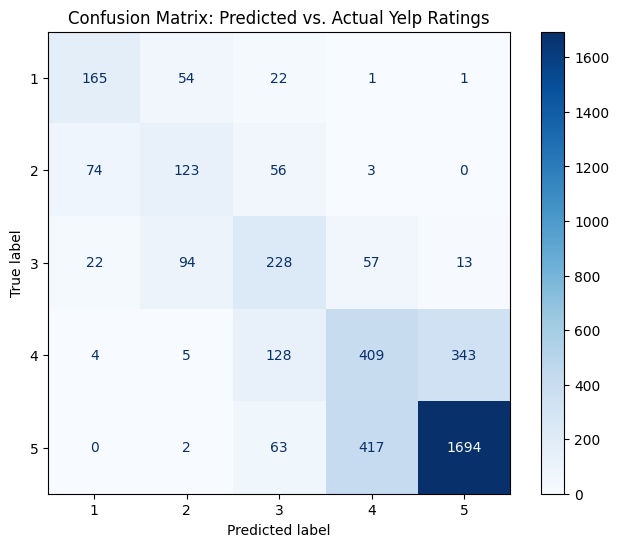

In [12]:
# Train and test the logistic regression model based on the Claude features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

X = clean_rated_df[["food_quality", "customer_service", "atmosphere", "value"]].values
y = clean_rated_df['Rating'].values

# Split and scale for training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
 
# Fit the classifier, adjust for the smaller number of low ratings by weighting
# them more heavily in the loss function.
clf = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)
 
# Evaluate on the test set
preds = clf.predict(X_test)
 
acc = accuracy_score(y_test, preds)
mae = np.abs(preds - y_test).mean()

# Print report.

print(f"Mean Absolute Error      : {mae:.4f}")
print(f"On average, the model is off by {mae:.2f} stars.")

print("--- Logistic Regression Classification Report ---")
print(classification_report(y_test, preds, target_names=["1 Star", "2 Stars", "3 Stars", "4 Stars", "5 Stars"]))

print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["1", "2", "3", "4", "5"])

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Predicted vs. Actual Yelp Ratings')
plt.show()

In [18]:
# Now we compare these results to asking claude to estimate the number of stars directly

def directly_rate_yelp_reviews(df: pd.DataFrame, text_column: str = "yelp_review", n_rows: int = 1000) -> pd.DataFrame:
    """
    Given dataframe with yelp_review column, sends each review to Claude API
    and obtains Claude's best guess of the number of stars earned. 
    Returns dataframe with rating fields added.
    Uses Haiku for cost efficiency and the Batch API.
    """
    client = anthropic.Anthropic(api_key=my_api_key)

    SYSTEM_PROMPT = """You will be given a Yelp review.  Please guess
    the number of stars that was given by the reviewer (integer between 1 and 5):

    Respond with ONLY with the single digit rating, no explanation:"""

    subset = df.head(n_rows).copy()

    # Build batch requests 
    requests = []
    for i, row in subset.iterrows():
        requests.append({
            "custom_id": str(i),
            "params": {
                "model": "claude-haiku-4-5-20251001",
                "max_tokens": 5,
                "system": SYSTEM_PROMPT,
                "messages": [
                    {"role": "user", "content": row[text_column]}
                ]
            }
        })

    # Submit batch 
    print(f"Submitting batch of {len(requests)} requests...")
    batch = client.messages.batches.create(requests=requests)
    batch_id = batch.id
    print(f"Batch submitted. ID: {batch_id}")

    # Poll until complete 
    while True:
        batch_status = client.messages.batches.retrieve(batch_id)
        status = batch_status.processing_status
        counts = batch_status.request_counts
        print(f"Status: {status} | "
              f"processing={counts.processing}, "
              f"succeeded={counts.succeeded}, "
              f"errored={counts.errored}")

        if status == "ended":
            break
        time.sleep(60)

    # Collect results 

    scores = {}
    errors = []

    for result in client.messages.batches.results(batch_id):
        row_id = int(result.custom_id)
        if result.result.type == "succeeded":
            scores[row_id] = result.result.message.content[0].text.strip()
        else:
            errors.append((row_id, f"API error: {result.result.type}"))
    if errors:
        print(f"\nWarning: {len(errors)} rows had issues:")
        for row_id, msg in errors[:10]:
            print(f"  Row {row_id}: {msg}")

    # Map scores back to dataframe 
    df = df.copy()
    
    df['claude_prediction'] = df.index.map(scores)

    succeeded = sum(1 for v in scores.values() if v is not None)
    print(f"\nDone. {succeeded}/{len(requests)} rows scored successfully.")
    return df

In [19]:
claude_classified_df = directly_rate_yelp_reviews(df, text_column="Review Text")

Submitting batch of 1000 requests...
Batch submitted. ID: msgbatch_01Nf8Nd78WWDrsjdznUbZZmg
Status: in_progress | processing=1000, succeeded=0, errored=0
Status: in_progress | processing=1000, succeeded=0, errored=0
Status: in_progress | processing=1000, succeeded=0, errored=0
Status: ended | processing=0, succeeded=1000, errored=0

Done. 1000/1000 rows scored successfully.


Mean Absolute Error      : 0.3120
On average, the model is off by 0.31 stars.
--- Claude Classification Report ---
              precision    recall  f1-score   support

      1 Star       0.73      0.79      0.76       168
     2 Stars       0.48      0.65      0.55       147
     3 Stars       0.80      0.41      0.54       166
     4 Stars       0.63      0.63      0.63       191
     5 Stars       0.82      0.86      0.84       328

    accuracy                           0.70      1000
   macro avg       0.69      0.67      0.66      1000
weighted avg       0.72      0.70      0.69      1000

--- Confusion Matrix ---


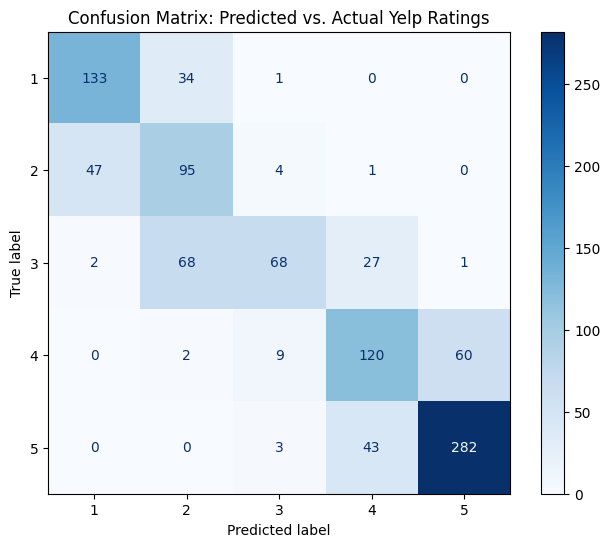

In [26]:
small_df=claude_classified_df.head(1000)

y = small_df['Rating'].values
preds = small_df['claude_prediction'].astype(int).values
 
acc = accuracy_score(y, preds)
mae = np.abs(preds - y).mean()

# Print report.

print(f"Mean Absolute Error      : {mae:.4f}")
print(f"On average, the model is off by {mae:.2f} stars.")

print("--- Claude Classification Report ---")
print(classification_report(y, preds, target_names=["1 Star", "2 Stars", "3 Stars", "4 Stars", "5 Stars"]))

print("--- Confusion Matrix ---")
cm = confusion_matrix(y, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["1", "2", "3", "4", "5"])

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Predicted vs. Actual Yelp Ratings')
plt.show()